============================================================================
 FINAL COMPARISON — ALL EMBEDDERS × ALL RERANKERS on Golden_eval
============================================================================

 Що робить:
   Кожен ембедер — dense-only + у комбінації з кожним реранкером.
   Всі метрики: NDCG@10, Precision@10, Recall@10, MAP@10, MRR@10.

 Чому оцінка НЕ через Qdrant:
   Golden_eval дає фіксований пул кандидатів (~55-65 CV на вакансію)
   з готовими human labels. Просто скоримо цей пул кожним методом
   і порівняємо порядок. Так порівняння чесне — всі бачать однакових
   кандидатів. Плюс не треба переіндексовувати Qdrant для кожного ембедера.

 Пам'ять:
   Ніколи не тримаємо >1 моделі в GPU одночасно. Фаза 1 — по черзі
   ембедимо всім ембедерами, зберігаємо scores + indices. Фаза 2 — по
   черзі ганяємо кожен реранкер на всіх ембедерських top-N.

 GPU: L4 24GB. Qwen-моделі у bf16, класичні у fp16.
============================================================================

In [22]:
# --- Cell 0.1: Залежності ---
!pip install -q "sentence-transformers>=5.0" "transformers>=4.51.0" qdrant-client pandas numpy scikit-learn

# --- Cell 0.2: Імпорти ---
import os
import glob
import gc
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from collections import Counter

from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics import ndcg_score
from qdrant_client import QdrantClient
from google.colab import drive, userdata

drive.mount("/content/drive")

device = "cuda" if torch.cuda.is_available() else "cpu"
device_name = torch.cuda.get_device_name(0) if device == "cuda" else "CPU"
print(f"GPU: {device_name}")
USE_BF16 = any(x in device_name for x in ["L4", "A100", "H100", "L40", "A10"])


# --- Cell 0.3: Конфіг ---
# ⚠ ЗВІР ШЛЯХИ на Drive із реальними. Скріншот показував ці — але у тебе
# у Drive могло бути дві копії з однаковими іменами. Перевір `!ls` перед запуском.
CFG = {
    # ─── EMBEDDERS ───────────────────────────────────────────────
    "embedders": {
        # Baseline pretrain — щоб бачити з чого починали
        "pretrain-Qwen3-Emb-0.6B":
            "Qwen/Qwen3-Embedding-0.6B",

        # Fine-tuned на auto-eval пулі
        # "qwen-retriever-v1 (auto-eval)":
        #     "/content/drive/MyDrive/qwen-cv-retriever-finetuned",   # Nan
        "qwen-retriever-v2 (auto-eval)":
            "/content/drive/MyDrive/qwen-cv-retriever-finetuned-v2",

        # Fine-tuned на golden set
        "qwen-retriever-v2 (golden)":
            "/content/drive/MyDrive/qwen-cv-retriever-finetuned-v2-golden-dataset",

        # Твоя опублікована на HF
        "cv_embedder (HF)":
            "ivvvvvi/cv_embedder",
    },

    # ─── RERANKERS ───────────────────────────────────────────────
    "rerankers": {
        # Baseline — оригінальний Qwen3 reranker
        "pretrain-Qwen3-Rerank-0.6B":
            "tomaarsen/Qwen3-Reranker-0.6B-seq-cls",

        # Твої натреновані на Drive
        "qwen3-rerank-FT":
            "/content/drive/MyDrive/qwen3-reranker-cv-finetuned",
        "qwen3-rerank-FT-distilled":
            "/content/drive/MyDrive/qwen3-reranker-cv-finetuned-distilled",
        "bge-rerank-FT-distilled":
            "/content/drive/MyDrive/bge-reranker-cv-finetuned-distilled"
    },

    # ─── ІНШЕ ────────────────────────────────────────────────────
    "collection_jobs": "illia_embedder_jobs",
    "golden_eval_dir": "/content/drive/MyDrive/CV_rank_Datasets/Golden_Eval",

    "retrieval_n": 30,           # скільки dense → rerank
    "eval_k": 10,                # k для метрик
    "rel_threshold": 2,          # label ≥ 2 = релевантний (для Precision/Recall/MAP/MRR)

    "max_cv_len": 2000,          # обрізка тексту
    "max_seq_length_emb": 1024,
    "max_seq_length_rerank": 512,

    # Промпти embedder — стандартні для asymmetric search
    "doc_prompt": "Represent this candidate CV for job matching retrieval",
    "query_prompt": "Find candidates matching this job vacancy",

    # Опціонально: пропустити baseline, якщо часу мало
    "skip_baseline_embedder": False,
    "skip_baseline_reranker": False,
}
print(f"Ембедерів: {len(CFG['embedders'])}, реранкерів: {len(CFG['rerankers'])}")
print(f"Комбінацій dense+rerank: {len(CFG['embedders']) * len(CFG['rerankers'])}")


# --- Cell 0.4: Qdrant (тільки щоб дістати тексти вакансій по job_id) ---
client = QdrantClient(
    url=userdata.get("QDRANT_URL"),
    api_key=userdata.get("QDRANT_API_KEY"),
    timeout=300,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: NVIDIA L4
Ембедерів: 4, реранкерів: 4
Комбінацій dense+rerank: 16


In [23]:
# --- Cell 1.1: Helpers ---
def strip_instruct(text):
    text = str(text)
    if "Query:" in text:
        return text.split("Query:", 1)[1].strip()
    return text.strip()


def clip(text, n=None):
    return str(text)[: (n or CFG["max_cv_len"])]


def vacancy_from_payload(p):
    if p.get("embed_text"):
        return clip(strip_instruct(p["embed_text"]))
    parts = []
    for key in ["title", "skills_tags", "experience_text"]:
        if p.get(key):
            parts.append(f"{key}: {p[key]}")
    return clip("\n".join(parts))


# --- Cell 1.2: Витяг вакансій з Qdrant + збірка Golden_eval ---
_vac_cache = {}
def get_vacancy_text(job_id):
    if job_id in _vac_cache:
        return _vac_cache[job_id]
    try:
        pts = client.retrieve(
            collection_name=CFG["collection_jobs"], ids=[job_id], with_payload=True
        )
        _vac_cache[job_id] = vacancy_from_payload(pts[0].payload) if pts else ""
    except Exception as e:
        print(f"  ⚠ {job_id}: {e}")
        _vac_cache[job_id] = ""
    return _vac_cache[job_id]


golden_files = sorted(glob.glob(f"{CFG['golden_eval_dir']}/*eval_pool_*.csv"))
if not golden_files:
    golden_files = sorted(glob.glob(f"{CFG['golden_eval_dir']}/*.csv"))
print(f"Знайдено файлів: {len(golden_files)}")

# golden_eval[job_id] = {'vacancy_text': ..., 'cvs': [...], 'labels': [...]}
golden_eval = {}
for path in tqdm(golden_files, desc="Читання Golden_eval"):
    df_g = pd.read_csv(path)
    if "job_id" not in df_g.columns or "cv_text" not in df_g.columns:
        continue
    jid = df_g["job_id"].iloc[0]
    vtext = get_vacancy_text(jid)
    if not vtext:
        continue

    cvs, labels = [], []
    for _, r in df_g.iterrows():
        if pd.notna(r.get("cv_text")):
            cvs.append(clip(r["cv_text"]))
            labels.append(int(r["Relevance_Score_0_to_3"]))

    # Викидаємо вакансії без жодного релевантного — метрики на них 0/undefined
    if any(l >= CFG["rel_threshold"] for l in labels):
        golden_eval[jid] = {"vacancy_text": vtext, "cvs": cvs, "labels": labels}

print(f"\nВакансій з релевантними кандидатами: {len(golden_eval)}")
print(f"Всього пар (vacancy, CV): "
      f"{sum(len(v['cvs']) for v in golden_eval.values())}")
print(f"Розподіл labels: "
      f"{dict(sorted(Counter(l for v in golden_eval.values() for l in v['labels']).items()))}")

Знайдено файлів: 10


Читання Golden_eval:   0%|          | 0/10 [00:00<?, ?it/s]


Вакансій з релевантними кандидатами: 10
Всього пар (vacancy, CV): 629
Розподіл labels: {0: 257, 1: 283, 2: 73, 3: 16}


In [25]:
# --- Cell 2.1: Реалізація ---
def compute_metrics(labels, scores, k=10, rel_threshold=2):
    """
    labels — ground truth 0-3
    scores — передбачені скори (більше = релевантніше)
    Повертає dict метрик @k.
    """
    labels = np.asarray(labels, dtype=float)
    scores = np.asarray(scores, dtype=float)
    order = np.argsort(-scores)          # спадання
    top_k = order[:k]

    rel = labels >= rel_threshold
    n_rel = int(rel.sum())

    ndcg = ndcg_score([labels], [scores], k=k) if labels.max() > 0 else 0.0

    hits = int(rel[top_k].sum())
    precision = hits / k
    recall = hits / n_rel if n_rel > 0 else 0.0

    ap, hit_c = 0.0, 0
    for rank_i, idx in enumerate(top_k, 1):
        if rel[idx]:
            hit_c += 1
            ap += hit_c / rank_i
    denom = min(n_rel, k)
    map_k = ap / denom if denom > 0 else 0.0

    mrr = 0.0
    for rank_i, idx in enumerate(top_k, 1):
        if rel[idx]:
            mrr = 1.0 / rank_i
            break

    return {"ndcg": ndcg, "precision": precision,
            "recall": recall, "map": map_k, "mrr": mrr}


def aggregate(per_vacancy_metrics, k):
    """Усереднює метрики по вакансіях."""
    keys = ["ndcg", "precision", "recall", "map", "mrr"]
    names = [f"NDCG@{k}", f"Precision@{k}", f"Recall@{k}", f"MAP@{k}", f"MRR@{k}"]
    return {
        name: float(np.mean([m[key] for m in per_vacancy_metrics]))
        if per_vacancy_metrics else 0.0
        for key, name in zip(keys, names)
    }

In [26]:
# --- Cell 3.1: Функція обрахунку dense scores ---
def compute_dense_scores(model, golden, batch_size=8):
    """
    Ембедить всі vacancies і CVs, повертає:
      {job_id: {'dense_scores': np.array, 'labels': [...], 'top_n_idx': np.array}}
    """
    out = {}
    N = CFG["retrieval_n"]

    for jid, data in tqdm(golden.items(), desc="  encoding", leave=False):
        vtext = data["vacancy_text"]
        cvs = data["cvs"]

        qv = model.encode(
            vtext, prompt=CFG["query_prompt"],
            normalize_embeddings=True,
        )
        dv = model.encode(
            cvs, prompt=CFG["doc_prompt"],
            normalize_embeddings=True,
            batch_size=batch_size, show_progress_bar=False,
        )
        dense_scores = (dv @ qv).astype(np.float32)
        top_n_idx = np.argsort(-dense_scores)[:N]

        out[jid] = {
            "dense_scores": dense_scores,
            "labels": data["labels"],
            "top_n_idx": top_n_idx,
        }
    return out


# --- Cell 3.2: Прогін усіх ембедерів ---
embedder_cache = {}  # {embedder_name: {job_id: {...}}}

for name, path in CFG["embedders"].items():
    if CFG["skip_baseline_embedder"] and "pretrain" in name.lower():
        print(f"⏭  {name} пропущено (skip_baseline_embedder)")
        continue

    print(f"\n▶ {name}")
    print(f"  {path}")
    try:
        model = SentenceTransformer(
            path,
            model_kwargs={"torch_dtype": torch.float16} if device == "cuda" else {},
        )
        model.max_seq_length = CFG["max_seq_length_emb"]
    except Exception as e:
        print(f"  ⚠ Не вдалось завантажити: {e}")
        continue

    # Sanity check — чи не NaN
    test = model.encode("test", normalize_embeddings=True)
    if np.isnan(test).any():
        print(f"  ❌ {name} видає NaN, пропускаю")
        del model
        gc.collect(); torch.cuda.empty_cache()
        continue

    embedder_cache[name] = compute_dense_scores(model, golden_eval)
    print(f"  ✅ dense scores для {len(embedder_cache[name])} вакансій")

    del model
    gc.collect()
    torch.cuda.empty_cache()

print(f"\nЗакешовано ембедерів: {len(embedder_cache)}")


▶ pretrain-Qwen3-Emb-0.6B
  Qwen/Qwen3-Embedding-0.6B


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  encoding:   0%|          | 0/10 [00:00<?, ?it/s]

  ✅ dense scores для 10 вакансій

▶ qwen-retriever-v2 (auto-eval)
  /content/drive/MyDrive/qwen-cv-retriever-finetuned-v2


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

...

  encoding:   0%|          | 0/10 [00:00<?, ?it/s]

  ✅ dense scores для 10 вакансій

▶ cv_embedder (HF)
  ivvvvvi/cv_embedder


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  encoding:   0%|          | 0/10 [00:00<?, ?it/s]

  ✅ dense scores для 10 вакансій

Закешовано ембедерів: 4


In [27]:
# --- Cell 4.1: Метрики кожного ембедера окремо (без реранку) ---
dense_only_results = []
k = CFG["eval_k"]

for name, per_vac in embedder_cache.items():
    per_vac_metrics = []
    for data in per_vac.values():
        per_vac_metrics.append(compute_metrics(
            data["labels"], data["dense_scores"],
            k=k, rel_threshold=CFG["rel_threshold"],
        ))
    row = {"Embedder": name, "Reranker": "— (dense only)"}
    row.update(aggregate(per_vac_metrics, k))
    dense_only_results.append(row)

dense_df = pd.DataFrame(dense_only_results)
print("\n" + "=" * 100)
print("DENSE-ONLY (без реранкера)")
print("=" * 100)
print(dense_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


DENSE-ONLY (без реранкера)
                     Embedder       Reranker  NDCG@10  Precision@10  Recall@10  MAP@10  MRR@10
      pretrain-Qwen3-Emb-0.6B — (dense only)   0.5968        0.3200     0.2707  0.1994  0.4200
qwen-retriever-v2 (auto-eval) — (dense only)   0.5943        0.3400     0.3276  0.2129  0.3560
   qwen-retriever-v2 (golden) — (dense only)   0.5943        0.3400     0.3276  0.2129  0.3560
             cv_embedder (HF) — (dense only)   0.6717        0.3700     0.3397  0.3486  0.7250


In [29]:
# --- Cell 5.1: Функція оцінки реранкера на одному ембедері ---
def eval_reranker_on_embedder(ce, embedder_data, golden, batch_size=16):
    per_vac_metrics = []
    for jid, edata in embedder_data.items():
        gdata = golden[jid]
        vtext = gdata["vacancy_text"]
        cvs = gdata["cvs"]
        labels = gdata["labels"]

        top_idx = edata["top_n_idx"]
        pairs = [[vtext, cvs[i]] for i in top_idx]
        rerank_scores = ce.predict(pairs, batch_size=batch_size, show_progress_bar=False)

        # Кандидати поза top-N — дуже маленький кінцевий скор,
        # значно менший за будь-який rerank score, щоб не потрапляли в топ.
        # Але НЕ -inf, бо ndcg_score його не приймає.
        rerank_scores = np.asarray(rerank_scores, dtype=np.float32)
        # Захист від NaN у rerank_scores (якщо реранкер видав щось погане)
        rerank_scores = np.nan_to_num(rerank_scores, nan=0.0, posinf=1e6, neginf=-1e6)

        min_finite = float(rerank_scores.min())
        fallback = min_finite - 1000.0  # гарантовано нижче за все

        final_scores = np.full(len(cvs), fallback, dtype=np.float32)
        final_scores[top_idx] = rerank_scores

        per_vac_metrics.append(compute_metrics(
            labels, final_scores, k=CFG["eval_k"],
            rel_threshold=CFG["rel_threshold"],
        ))
    return per_vac_metrics


# --- Cell 5.2: Прогін усіх реранкерів × усіх ембедерів ---
rerank_results = []
k = CFG["eval_k"]

for rr_name, rr_path in CFG["rerankers"].items():
    if CFG["skip_baseline_reranker"] and "pretrain" in rr_name.lower():
        print(f"⏭  {rr_name} пропущено")
        continue

    print(f"\n▶ Reranker: {rr_name}")
    print(f"  {rr_path}")
    try:
        # Qwen у bf16, bge у fp16 (класичний encoder)
        is_qwen = "qwen" in rr_name.lower()
        dtype = torch.bfloat16 if (is_qwen and USE_BF16) else torch.float16
        ce = CrossEncoder(
            rr_path,
            max_length=CFG["max_seq_length_rerank"],
            model_kwargs={"torch_dtype": dtype} if device == "cuda" else {},
        )
    except Exception as e:
        print(f"  ⚠ Не вдалось завантажити: {e}")
        continue

    # Sanity check
    test = ce.predict([["query", "doc"]])
    if np.isnan(test).any():
        print(f"  ❌ NaN, пропускаю")
        del ce; gc.collect(); torch.cuda.empty_cache()
        continue

    for emb_name, edata in embedder_cache.items():
        per_vac_metrics = eval_reranker_on_embedder(ce, edata, golden_eval)
        row = {"Embedder": emb_name, "Reranker": rr_name}
        row.update(aggregate(per_vac_metrics, k))
        rerank_results.append(row)
        print(f"  ✔ {emb_name}: NDCG@{k}={row[f'NDCG@{k}']:.4f}")

    del ce
    gc.collect()
    torch.cuda.empty_cache()

rerank_df = pd.DataFrame(rerank_results)


▶ Reranker: pretrain-Qwen3-Rerank-0.6B
  tomaarsen/Qwen3-Reranker-0.6B-seq-cls


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

  ✔ pretrain-Qwen3-Emb-0.6B: NDCG@10=0.4270
  ✔ qwen-retriever-v2 (auto-eval): NDCG@10=0.4316
  ✔ qwen-retriever-v2 (golden): NDCG@10=0.4316
  ✔ cv_embedder (HF): NDCG@10=0.4509

▶ Reranker: qwen3-rerank-FT
  /content/drive/MyDrive/qwen3-reranker-cv-finetuned


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

  ✔ pretrain-Qwen3-Emb-0.6B: NDCG@10=0.5704
  ✔ qwen-retriever-v2 (auto-eval): NDCG@10=0.5821
  ✔ qwen-retriever-v2 (golden): NDCG@10=0.5821
  ✔ cv_embedder (HF): NDCG@10=0.5932

▶ Reranker: qwen3-rerank-FT-distilled
  /content/drive/MyDrive/qwen3-reranker-cv-finetuned-distilled


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

  ✔ pretrain-Qwen3-Emb-0.6B: NDCG@10=0.5772
  ✔ qwen-retriever-v2 (auto-eval): NDCG@10=0.5623
  ✔ qwen-retriever-v2 (golden): NDCG@10=0.5623
  ✔ cv_embedder (HF): NDCG@10=0.5716

▶ Reranker: bge-rerank-FT-distilled
  /content/drive/MyDrive/bge-reranker-cv-finetuned-distilled


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

  ✔ pretrain-Qwen3-Emb-0.6B: NDCG@10=0.5010
  ✔ qwen-retriever-v2 (auto-eval): NDCG@10=0.4942
  ✔ qwen-retriever-v2 (golden): NDCG@10=0.4942
  ✔ cv_embedder (HF): NDCG@10=0.5493


In [30]:
# --- Cell 6.1: Об'єднана таблиця ---
full_df = pd.concat([dense_df, rerank_df], ignore_index=True)

metric_cols = [f"NDCG@{k}", f"Precision@{k}", f"Recall@{k}", f"MAP@{k}", f"MRR@{k}"]
full_df = full_df.sort_values(f"NDCG@{k}", ascending=False).reset_index(drop=True)

print("\n" + "=" * 110)
print(f"ФІНАЛЬНА ТАБЛИЦЯ — {len(golden_eval)} вакансій, сортовано за NDCG@{k}")
print("=" * 110)
print(full_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



ФІНАЛЬНА ТАБЛИЦЯ — 10 вакансій, сортовано за NDCG@10
                     Embedder                   Reranker  NDCG@10  Precision@10  Recall@10  MAP@10  MRR@10
             cv_embedder (HF)             — (dense only)   0.6717        0.3700     0.3397  0.3486  0.7250
      pretrain-Qwen3-Emb-0.6B             — (dense only)   0.5968        0.3200     0.2707  0.1994  0.4200
qwen-retriever-v2 (auto-eval)             — (dense only)   0.5943        0.3400     0.3276  0.2129  0.3560
   qwen-retriever-v2 (golden)             — (dense only)   0.5943        0.3400     0.3276  0.2129  0.3560
             cv_embedder (HF)            qwen3-rerank-FT   0.5932        0.3000     0.4265  0.2399  0.6176
qwen-retriever-v2 (auto-eval)            qwen3-rerank-FT   0.5821        0.3000     0.3401  0.2316  0.6476
   qwen-retriever-v2 (golden)            qwen3-rerank-FT   0.5821        0.3000     0.3401  0.2316  0.6476
      pretrain-Qwen3-Emb-0.6B  qwen3-rerank-FT-distilled   0.5772        0.3100     0.3564

In [31]:

# --- Cell 6.2: Топ-5 конфігурацій ---
print("\n" + "=" * 110)
print(f"🏆 TOP-5 конфігурацій за NDCG@{k}")
print("=" * 110)
print(full_df.head(5).to_string(index=False, float_format=lambda x: f"{x:.4f}"))


🏆 TOP-5 конфігурацій за NDCG@10
                     Embedder        Reranker  NDCG@10  Precision@10  Recall@10  MAP@10  MRR@10
             cv_embedder (HF)  — (dense only)   0.6717        0.3700     0.3397  0.3486  0.7250
      pretrain-Qwen3-Emb-0.6B  — (dense only)   0.5968        0.3200     0.2707  0.1994  0.4200
qwen-retriever-v2 (auto-eval)  — (dense only)   0.5943        0.3400     0.3276  0.2129  0.3560
   qwen-retriever-v2 (golden)  — (dense only)   0.5943        0.3400     0.3276  0.2129  0.3560
             cv_embedder (HF) qwen3-rerank-FT   0.5932        0.3000     0.4265  0.2399  0.6176


In [32]:
# --- Cell 6.3: Найкращий реранкер під кожен ембедер ---
print("\n" + "=" * 110)
print(f"Найкращий РЕРАНКЕР для кожного ембедера (за NDCG@{k})")
print("=" * 110)
best_per_emb = (
    full_df[full_df["Reranker"] != "— (dense only)"]
    .sort_values(f"NDCG@{k}", ascending=False)
    .groupby("Embedder").head(1)
    .sort_values(f"NDCG@{k}", ascending=False)
)
print(best_per_emb.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Найкращий РЕРАНКЕР для кожного ембедера (за NDCG@10)
                     Embedder                  Reranker  NDCG@10  Precision@10  Recall@10  MAP@10  MRR@10
             cv_embedder (HF)           qwen3-rerank-FT   0.5932        0.3000     0.4265  0.2399  0.6176
qwen-retriever-v2 (auto-eval)           qwen3-rerank-FT   0.5821        0.3000     0.3401  0.2316  0.6476
   qwen-retriever-v2 (golden)           qwen3-rerank-FT   0.5821        0.3000     0.3401  0.2316  0.6476
      pretrain-Qwen3-Emb-0.6B qwen3-rerank-FT-distilled   0.5772        0.3100     0.3564  0.2229  0.6611


In [33]:
# --- Cell 6.4: Найкращий ембедер під кожен реранкер ---
print("\n" + "=" * 110)
print(f"Найкращий ЕМБЕДЕР для кожного реранкера (за NDCG@{k})")
print("=" * 110)
best_per_rr = (
    rerank_df.sort_values(f"NDCG@{k}", ascending=False)
    .groupby("Reranker").head(1)
    .sort_values(f"NDCG@{k}", ascending=False)
)
print(best_per_rr.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Найкращий ЕМБЕДЕР для кожного реранкера (за NDCG@10)
               Embedder                   Reranker  NDCG@10  Precision@10  Recall@10  MAP@10  MRR@10
       cv_embedder (HF)            qwen3-rerank-FT   0.5932        0.3000     0.4265  0.2399  0.6176
pretrain-Qwen3-Emb-0.6B  qwen3-rerank-FT-distilled   0.5772        0.3100     0.3564  0.2229  0.6611
       cv_embedder (HF)    bge-rerank-FT-distilled   0.5493        0.2700     0.3701  0.1526  0.4071
       cv_embedder (HF) pretrain-Qwen3-Rerank-0.6B   0.4509        0.2300     0.3259  0.1693  0.4708


In [34]:
# --- Cell 6.5: Приріст від реранкера для кожного ембедера ---
print("\n" + "=" * 110)
print(f"Приріст NDCG@{k} від найкращого реранкера порівняно з dense-only")
print("=" * 110)
gains = []
for emb in embedder_cache.keys():
    dense_ndcg = dense_df.loc[dense_df["Embedder"] == emb, f"NDCG@{k}"].values[0]
    best_row = best_per_emb[best_per_emb["Embedder"] == emb].iloc[0]
    best_ndcg = best_row[f"NDCG@{k}"]
    gains.append({
        "Embedder": emb,
        "Dense-only NDCG": dense_ndcg,
        "Best reranker": best_row["Reranker"],
        "Best NDCG": best_ndcg,
        "Δ": best_ndcg - dense_ndcg,
        "Δ%": (best_ndcg - dense_ndcg) / dense_ndcg * 100 if dense_ndcg > 0 else 0,
    })
gains_df = pd.DataFrame(gains).sort_values("Δ", ascending=False)
print(gains_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Приріст NDCG@10 від найкращого реранкера порівняно з dense-only
                     Embedder  Dense-only NDCG             Best reranker  Best NDCG       Δ       Δ%
qwen-retriever-v2 (auto-eval)           0.5943           qwen3-rerank-FT     0.5821 -0.0122  -2.0466
   qwen-retriever-v2 (golden)           0.5943           qwen3-rerank-FT     0.5821 -0.0122  -2.0466
      pretrain-Qwen3-Emb-0.6B           0.5968 qwen3-rerank-FT-distilled     0.5772 -0.0196  -3.2773
             cv_embedder (HF)           0.6717           qwen3-rerank-FT     0.5932 -0.0785 -11.6878


In [35]:
# --- Cell 6.6: Матриця NDCG@10 ембедер × реранкер ---
print("\n" + "=" * 110)
print(f"МАТРИЦЯ NDCG@{k} — ембедери (рядки) × реранкери (колонки)")
print("=" * 110)
matrix = rerank_df.pivot(index="Embedder", columns="Reranker", values=f"NDCG@{k}")
# Додаємо колонку dense-only для контексту
dense_col = dense_df.set_index("Embedder")[f"NDCG@{k}"]
matrix.insert(0, "— dense only", dense_col)
print(matrix.to_string(float_format=lambda x: f"{x:.4f}"))


МАТРИЦЯ NDCG@10 — ембедери (рядки) × реранкери (колонки)
Reranker                       — dense only  bge-rerank-FT-distilled  pretrain-Qwen3-Rerank-0.6B  qwen3-rerank-FT  qwen3-rerank-FT-distilled
Embedder                                                                                                                                    
cv_embedder (HF)                     0.6717                   0.5493                      0.4509           0.5932                     0.5716
pretrain-Qwen3-Emb-0.6B              0.5968                   0.5010                      0.4270           0.5704                     0.5772
qwen-retriever-v2 (auto-eval)        0.5943                   0.4942                      0.4316           0.5821                     0.5623
qwen-retriever-v2 (golden)           0.5943                   0.4942                      0.4316           0.5821                     0.5623


In [36]:
# --- Cell 7.1: CSV ---
out_dir = "/content/drive/MyDrive/CV_rank_Datasets/results"
os.makedirs(out_dir, exist_ok=True)

full_df.to_csv(f"{out_dir}/final_comparison_all.csv", index=False)
gains_df.to_csv(f"{out_dir}/rerank_gains.csv", index=False)
matrix.to_csv(f"{out_dir}/ndcg_matrix.csv")

print(f"\nЗбережено:")
print(f"  {out_dir}/final_comparison_all.csv  — повна таблиця, {len(full_df)} рядків")
print(f"  {out_dir}/rerank_gains.csv          — приріст від реранкера")
print(f"  {out_dir}/ndcg_matrix.csv           — матриця NDCG")


Збережено:
  /content/drive/MyDrive/CV_rank_Datasets/results/final_comparison_all.csv  — повна таблиця, 20 рядків
  /content/drive/MyDrive/CV_rank_Datasets/results/rerank_gains.csv          — приріст від реранкера
  /content/drive/MyDrive/CV_rank_Datasets/results/ndcg_matrix.csv           — матриця NDCG


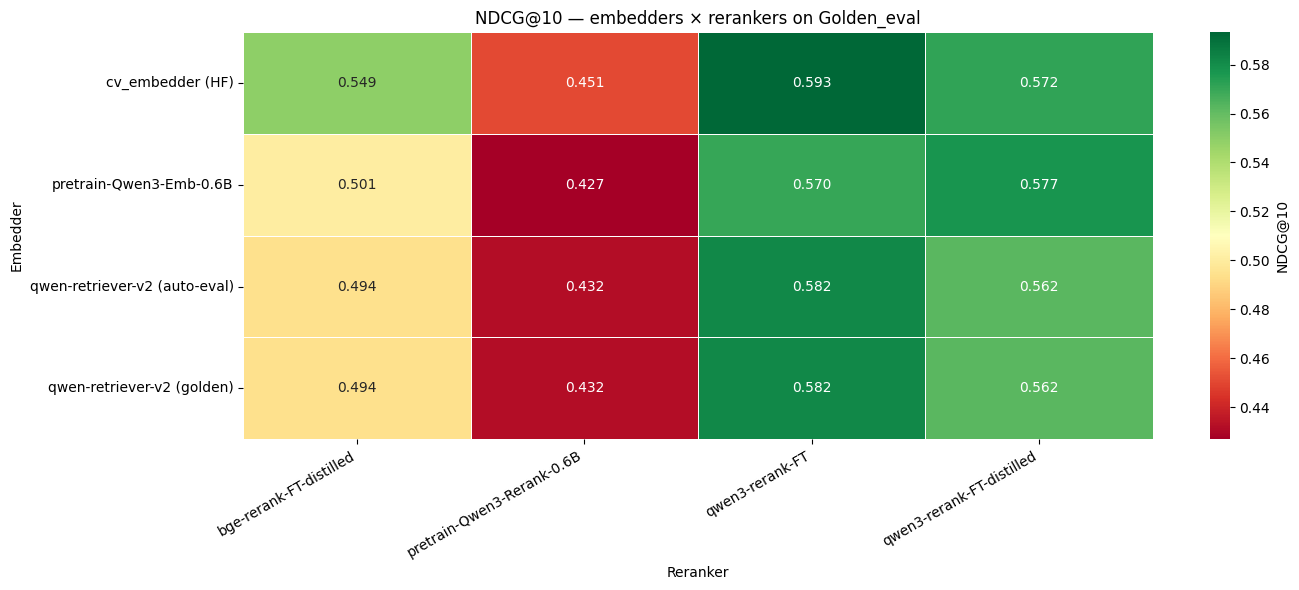

  /content/drive/MyDrive/CV_rank_Datasets/results/ndcg_heatmap_v2.png


In [44]:
# --- Cell 7.2: Heatmap (опційно, для презентації) ---
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        matrix.drop(columns=["— dense only"]), annot=True, fmt=".3f", cmap="RdYlGn",
        cbar_kws={"label": f"NDCG@{k}"}, linewidths=0.5, ax=ax,
    )
    ax.set_title(f"NDCG@{k} — embedders × rerankers on Golden_eval")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{out_dir}/ndcg_heatmap_v2.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  {out_dir}/ndcg_heatmap_v2.png")
except Exception as e:
    print(f"  ⚠ heatmap: {e}")

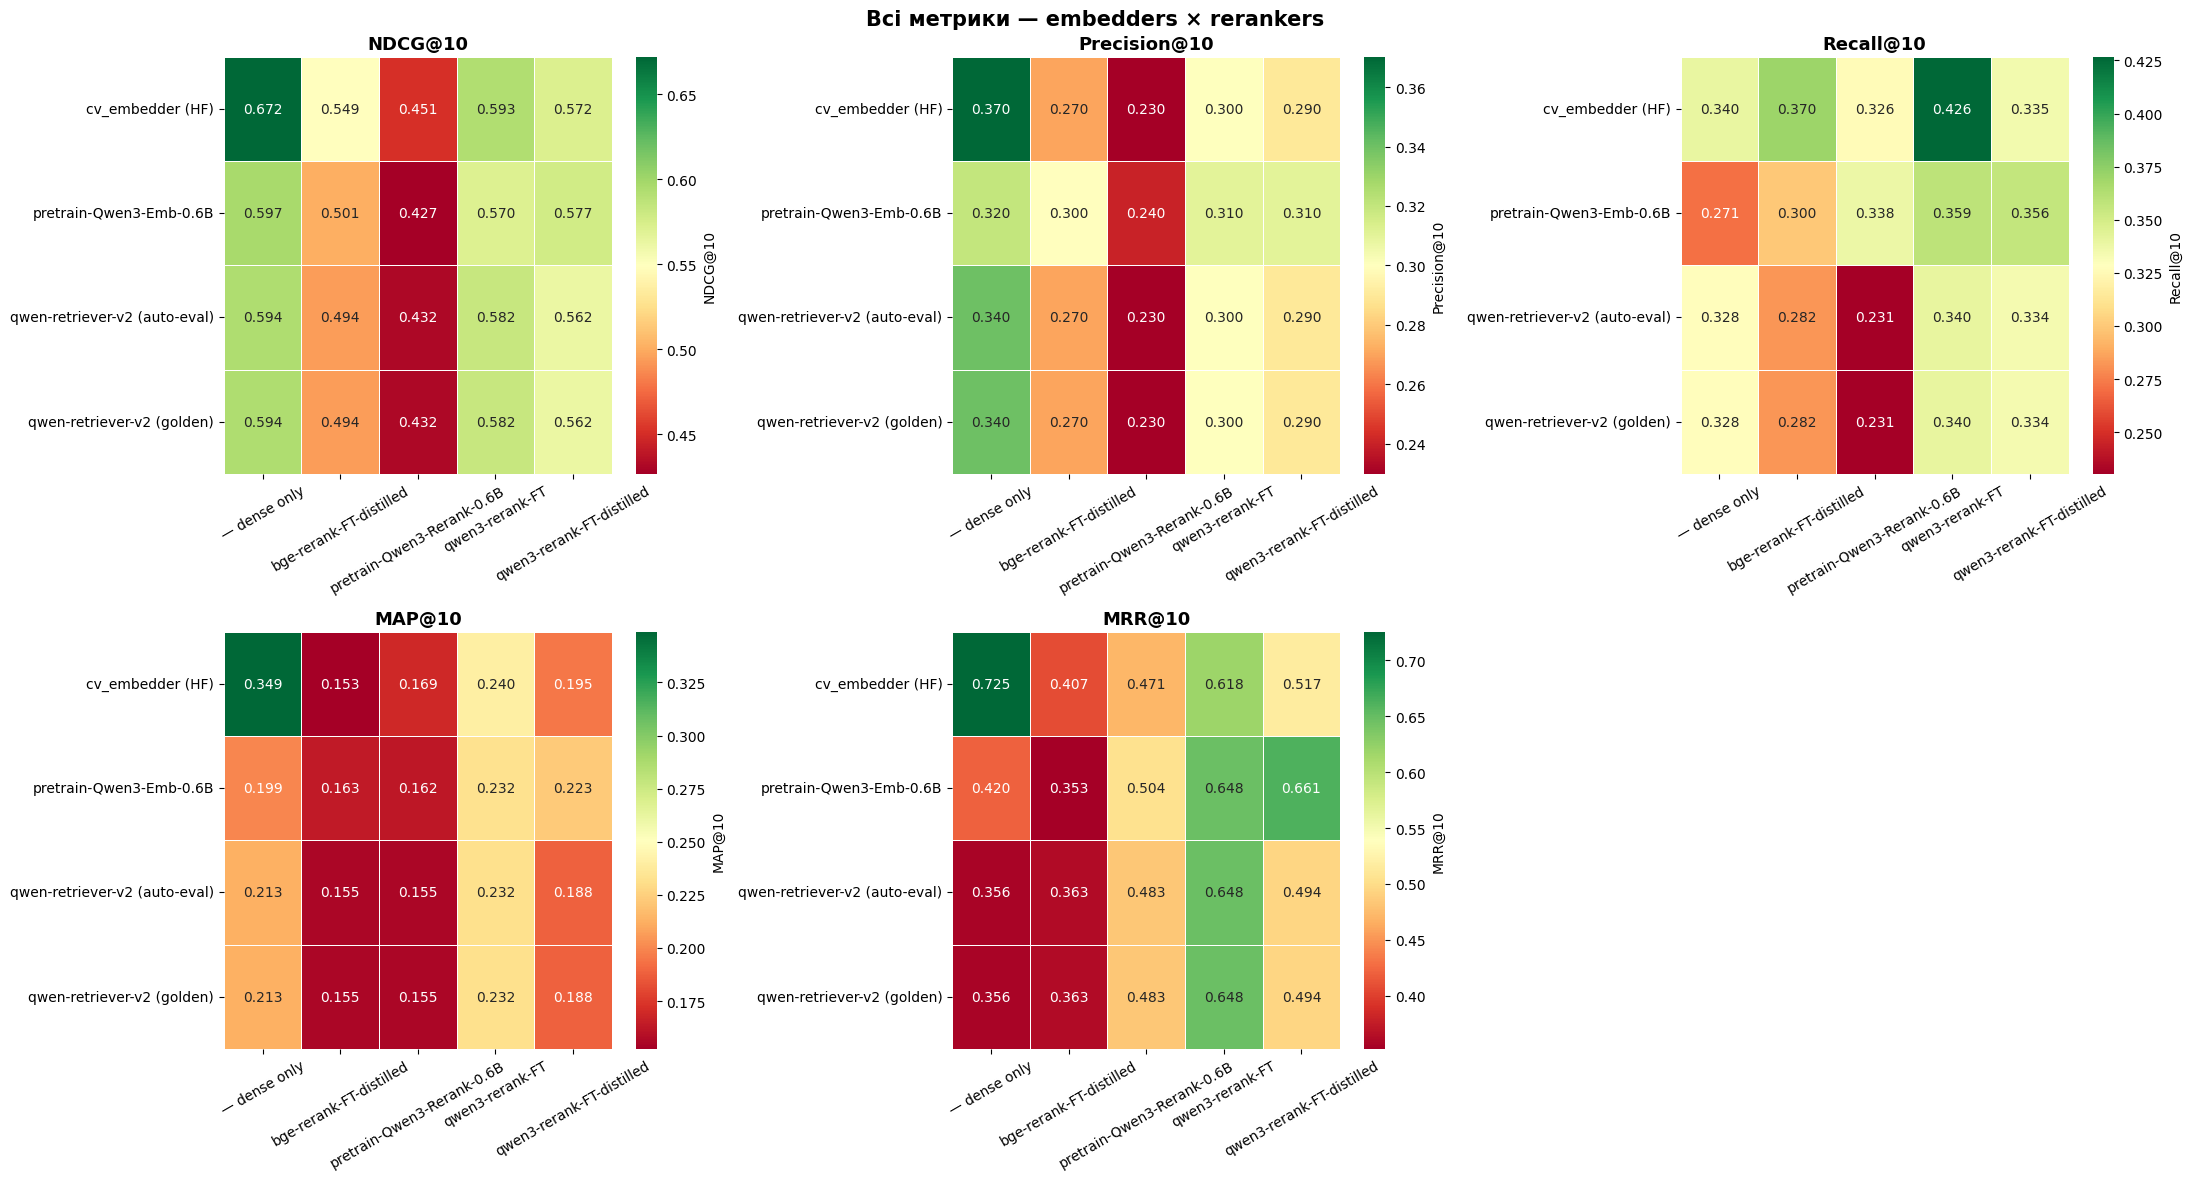

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics = ["NDCG@10", "Precision@10", "Recall@10", "MAP@10", "MRR@10"]

# ─────────────────────────────────────────────────────────────
# 1. Heatmaps для ВСІХ метрик, не тільки NDCG
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    m = rerank_df.pivot(index="Embedder", columns="Reranker", values=metric)
    m.insert(0, "— dense only", dense_df.set_index("Embedder")[metric])

    sns.heatmap(
        m, annot=True, fmt=".3f", cmap="RdYlGn",
        cbar_kws={"label": metric}, linewidths=0.5,
        ax=axes[i], vmin=m.values.min(), vmax=m.values.max(),
    )
    axes[i].set_title(metric, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].tick_params(axis="y", rotation=0)

axes[-1].axis("off")   # прибираємо порожню шосту клітинку
plt.suptitle("Всі метрики — embedders × rerankers", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{out_dir}/all_metrics_heatmaps.png", dpi=140, bbox_inches="tight")
plt.show()

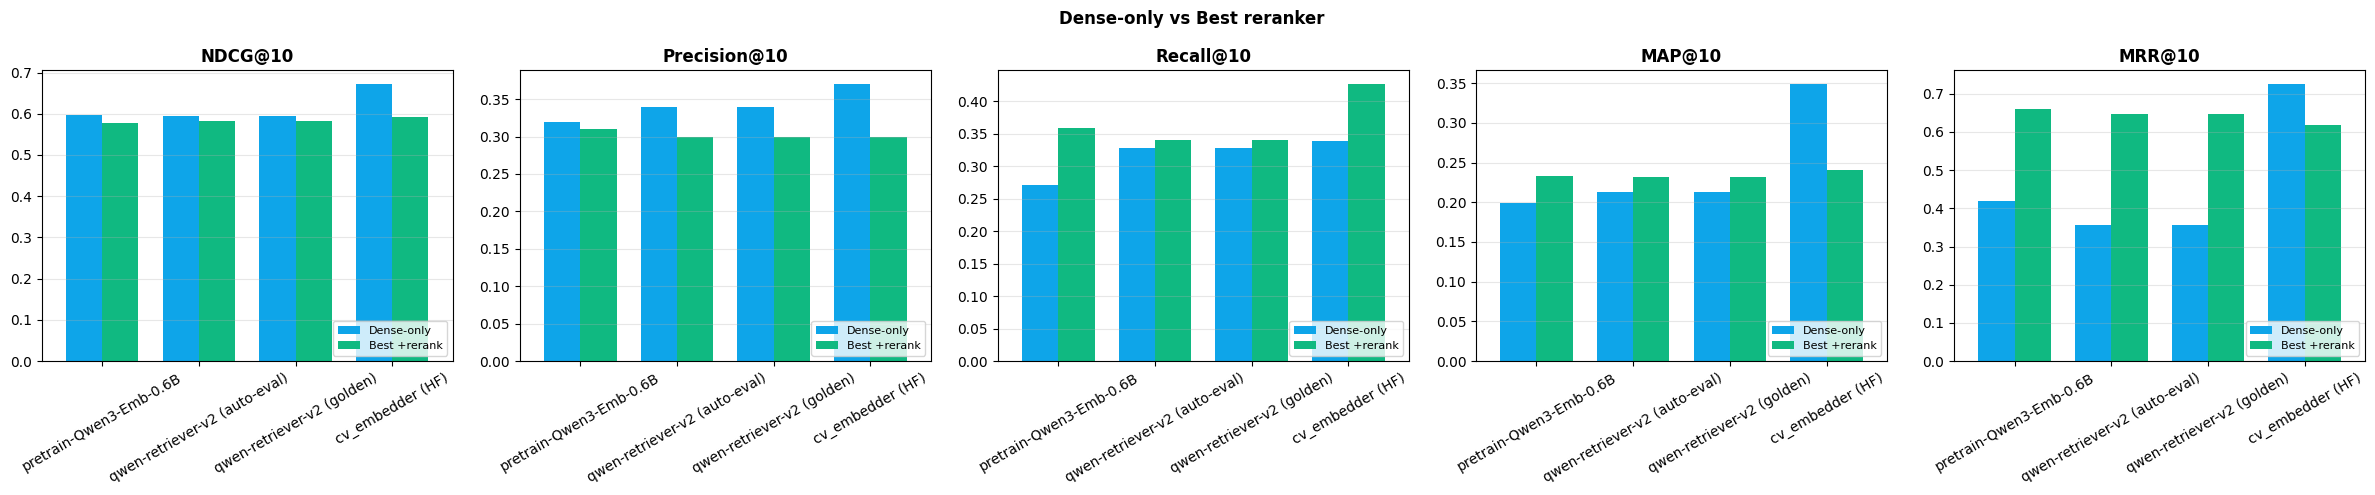

In [46]:
fig, axes = plt.subplots(1, len(metrics), figsize=(24, 5), sharey=False)

for ax, metric in zip(axes, metrics):
    rows = []
    for emb in dense_df["Embedder"]:
        dense_val = dense_df.loc[dense_df["Embedder"] == emb, metric].values[0]
        rr_rows = rerank_df[rerank_df["Embedder"] == emb]
        best_val = rr_rows[metric].max() if len(rr_rows) else 0
        rows.append({"Embedder": emb, "Dense-only": dense_val, "Best +rerank": best_val})

    plot_df = pd.DataFrame(rows).set_index("Embedder")
    plot_df.plot(kind="bar", ax=ax, color=["#0EA5E9", "#10B981"], width=0.75)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Dense-only vs Best reranker", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{out_dir}/dense_vs_rerank_bars.png", dpi=140, bbox_inches="tight")
plt.show()

In [47]:
def highlight_best(s):
    return ["background-color: #10B981; color: white; font-weight: bold"
            if v == s.max() else "" for v in s]

styled = (
    full_df.style
        .format({m: "{:.4f}" for m in metrics})
        .apply(highlight_best, subset=metrics)
        .set_caption(f"Всі конфігурації на Golden_eval ({len(golden_eval)} вакансій)")
)
display(styled)

,Embedder,Reranker,NDCG@10,Precision@10,Recall@10,MAP@10,MRR@10
0,cv_embedder (HF),— (dense only),0.6717,0.3700,0.3397,0.3486,0.7250
1,pretrain-Qwen3-Emb-0.6B,— (dense only),0.5968,0.3200,0.2707,0.1994,0.4200
2,qwen-retriever-v2 (auto-eval),— (dense only),0.5943,0.3400,0.3276,0.2129,0.3560
3,qwen-retriever-v2 (golden),— (dense only),0.5943,0.3400,0.3276,0.2129,0.3560
4,cv_embedder (HF),qwen3-rerank-FT,0.5932,0.3000,0.4265,0.2399,0.6176
5,qwen-retriever-v2 (auto-eval),qwen3-rerank-FT,0.5821,0.3000,0.3401,0.2316,0.6476
6,qwen-retriever-v2 (golden),qwen3-rerank-FT,0.5821,0.3000,0.3401,0.2316,0.6476
7,pretrain-Qwen3-Emb-0.6B,qwen3-rerank-FT-distilled,0.5772,0.3100,0.3564,0.2229,0.6611
8,cv_embedder (HF),qwen3-rerank-FT-distilled,0.5716,0.2900,0.3347,0.1955,0.5167
9,pretrain-Qwen3-Emb-0.6B,qwen3-rerank-FT,0.5704,0.3100,0.3589,0.2325,0.6476


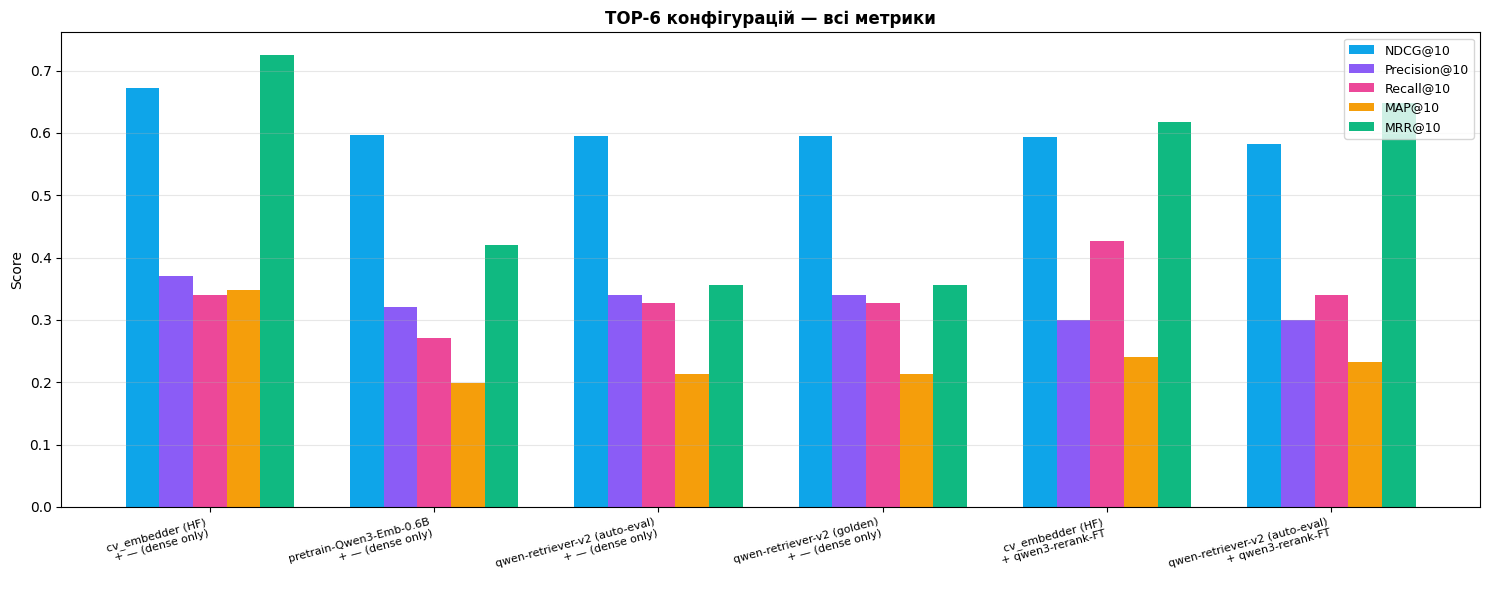


Всі графіки збережено в /content/drive/MyDrive/CV_rank_Datasets/results/


In [48]:
TOP_N = 6
top_configs = full_df.nlargest(TOP_N, "NDCG@10").copy()
top_configs["Config"] = top_configs["Embedder"] + "\n+ " + top_configs["Reranker"]

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(top_configs))
width = 0.15
colors = ["#0EA5E9", "#8B5CF6", "#EC4899", "#F59E0B", "#10B981"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, top_configs[metric], width, label=metric, color=color)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(top_configs["Config"], rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Score")
ax.set_title(f"TOP-{TOP_N} конфігурацій — всі метрики", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{out_dir}/top_configs_all_metrics.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"\nВсі графіки збережено в {out_dir}/")